In [3]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

print("E-Commerce Analytics Project Started")


E-Commerce Analytics Project Started


In [4]:
data = {
    "order_id": [
        1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010,
        1011, 1012, 1013, 1014, 1015,
        1016, 1017, 1018, 1019, 1020
    ],
    
    "date": [
        "2026-01-05", "2026-01-08", "2026-01-12", "2026-01-20", "2026-01-28",
        "2026-02-03", "2026-02-10", "2026-02-18", "2026-02-25", "2026-03-04",
        "2026-03-12", "2026-03-20", "2026-03-28", "2026-04-05", "2026-04-15",
        "2026-04-22", "2026-05-02", "2026-05-12", "2026-05-20", "2026-05-28"
    ],
    
    "customer": [
        "Rahul", "Priya", "Arjun", "Sneha", "Kiran",
        "Rahul", "Priya", "Arjun", "Sneha", "Kiran",
        "Rahul", "Priya", "Arjun", "Sneha", "Kiran",
        "Rahul", "Priya", "Arjun", "Sneha", "Kiran"
    ],
    
    "product": [
        "Laptop", "Mouse", "Keyboard", "Monitor", "Headphones",
        "Laptop", "Keyboard", "Mouse", "Monitor", "Laptop",
        "Headphones", "Keyboard", "Laptop", "Mouse", "Monitor",
        "Headphones", "Laptop", "Keyboard", "Mouse", "Monitor"
    ],
    
    "category": [
        "Electronics", "Accessories", "Accessories", "Electronics", "Accessories",
        "Electronics", "Accessories", "Accessories", "Electronics", "Electronics",
        "Accessories", "Accessories", "Electronics", "Accessories", "Electronics",
        "Accessories", "Electronics", "Accessories", "Accessories", "Electronics"
    ],
    
    "quantity": [
        1, 3, 2, 1, 2,
        1, 4, 5, 2, 1,
        3, 2, 2, 6, 1,
        4, 1, 3, 5, 2
    ],
    
    "unit_price": [
        55000, 800, 1500, 12000, 2500,
        55000, 1500, 800, 12000, 55000,
        2500, 1500, 55000, 800, 12000,
        2500, 55000, 1500, 800, 12000
    ],
    
    "region": [
        "South", "North", "South", "West", "East",
        "South", "North", "South", "West", "East",
        "South", "North", "South", "West", "East",
        "South", "North", "South", "West", "East"
    ]
}

df = pd.DataFrame(data)

df.head()


,order_id,date,customer,product,category,quantity,unit_price,region
0,1001,2026-01-05,Rahul,Laptop,Electronics,1,55000,South
1,1002,2026-01-08,Priya,Mouse,Accessories,3,800,North
2,1003,2026-01-12,Arjun,Keyboard,Accessories,2,1500,South
3,1004,2026-01-20,Sneha,Monitor,Electronics,1,12000,West
4,1005,2026-01-28,Kiran,Headphones,Accessories,2,2500,East


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (20, 8)

Columns:
['order_id', 'date', 'customer', 'product', 'category', 'quantity', 'unit_price', 'region']

Data Types:
order_id       int64
date          object
customer      object
product       object
category      object
quantity       int64
unit_price     int64
region        object
dtype: object

Missing Values:
order_id      0
date          0
customer      0
product       0
category      0
quantity      0
unit_price    0
region        0
dtype: int64


In [6]:
df["date"] = pd.to_datetime(df["date"])

df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")

df = df.drop_duplicates()

df = df.dropna()

df["revenue"] = df["quantity"] * df["unit_price"]

df["month"] = df["date"].dt.to_period("M").astype(str)

print("Data cleaning and transformation completed.")

df.head()


Data cleaning and transformation completed.


,order_id,date,customer,product,category,quantity,unit_price,region,revenue,month
0,1001,2026-01-05,Rahul,Laptop,Electronics,1,55000,South,55000,2026-01
1,1002,2026-01-08,Priya,Mouse,Accessories,3,800,North,2400,2026-01
2,1003,2026-01-12,Arjun,Keyboard,Accessories,2,1500,South,3000,2026-01
3,1004,2026-01-20,Sneha,Monitor,Electronics,1,12000,West,12000,2026-01
4,1005,2026-01-28,Kiran,Headphones,Accessories,2,2500,East,5000,2026-01


In [7]:
print("Total Orders:", df["order_id"].nunique())
print("Total Units Sold:", df["quantity"].sum())
print("Total Revenue: ₹{:,.2f}".format(df["revenue"].sum()))
print("Average Order Value: ₹{:,.2f}".format(df["revenue"].mean()))


Total Orders: 20
Total Units Sold: 51
Total Revenue: ₹456,200.00
Average Order Value: ₹22,810.00


In [8]:
conn = sqlite3.connect("ecommerce.db")

df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("Sales data successfully loaded into SQLite.")


Sales data successfully loaded into SQLite.


In [9]:
query = """
SELECT *
FROM sales
LIMIT 5;
"""

result = pd.read_sql_query(query, conn)

result


,order_id,date,customer,product,category,quantity,unit_price,region,revenue,month
0,1001,2026-01-05 00:00:00,Rahul,Laptop,Electronics,1,55000,South,55000,2026-01
1,1002,2026-01-08 00:00:00,Priya,Mouse,Accessories,3,800,North,2400,2026-01
2,1003,2026-01-12 00:00:00,Arjun,Keyboard,Accessories,2,1500,South,3000,2026-01
3,1004,2026-01-20 00:00:00,Sneha,Monitor,Electronics,1,12000,West,12000,2026-01
4,1005,2026-01-28 00:00:00,Kiran,Headphones,Accessories,2,2500,East,5000,2026-01


In [10]:
query = """
SELECT 
    product,
    SUM(quantity) AS units_sold,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY product
ORDER BY total_revenue DESC;
"""

product_analysis = pd.read_sql_query(query, conn)

product_analysis


,product,units_sold,total_revenue
0,Laptop,6,330000
1,Monitor,6,72000
2,Headphones,9,22500
3,Keyboard,11,16500
4,Mouse,19,15200


In [11]:
query = """
SELECT 
    category,
    SUM(quantity) AS units_sold,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY category
ORDER BY total_revenue DESC;
"""

category_analysis = pd.read_sql_query(query, conn)

category_analysis


,category,units_sold,total_revenue
0,Electronics,12,402000
1,Accessories,39,54200


In [12]:
query = """
SELECT 
    region,
    COUNT(*) AS total_orders,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY region
ORDER BY total_revenue DESC;
"""

region_analysis = pd.read_sql_query(query, conn)

region_analysis


,region,total_orders,total_revenue
0,South,8,249000
1,East,4,96000
2,North,4,66400
3,West,4,44800


In [13]:
customers = pd.DataFrame({
    "customer_id": [1, 2, 3, 4, 5],
    "customer": ["Rahul", "Priya", "Arjun", "Sneha", "Kiran"],
    "age": [22, 24, 21, 23, 25],
    "city": ["Vijayawada", "Hyderabad", "Guntur", "Chennai", "Bengaluru"]
})

customers


,customer_id,customer,age,city
0,1,Rahul,22,Vijayawada
1,2,Priya,24,Hyderabad
2,3,Arjun,21,Guntur
3,4,Sneha,23,Chennai
4,5,Kiran,25,Bengaluru


In [14]:
customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Customers table created successfully.")


Customers table created successfully.


In [15]:
query = """
SELECT
    s.order_id,
    s.customer,
    c.city,
    c.age,
    s.product,
    s.revenue
FROM sales s
JOIN customers c
    ON s.customer = c.customer;
"""

joined_data = pd.read_sql_query(query, conn)

joined_data.head(10)


,order_id,customer,city,age,product,revenue
0,1001,Rahul,Vijayawada,22,Laptop,55000
1,1002,Priya,Hyderabad,24,Mouse,2400
2,1003,Arjun,Guntur,21,Keyboard,3000
3,1004,Sneha,Chennai,23,Monitor,12000
4,1005,Kiran,Bengaluru,25,Headphones,5000
5,1006,Rahul,Vijayawada,22,Laptop,55000
6,1007,Priya,Hyderabad,24,Keyboard,6000
7,1008,Arjun,Guntur,21,Mouse,4000
8,1009,Sneha,Chennai,23,Monitor,24000
9,1010,Kiran,Bengaluru,25,Laptop,55000


In [16]:
query = """
SELECT
    customer,
    COUNT(order_id) AS total_orders,
    SUM(revenue) AS total_spending,
    AVG(revenue) AS average_order_value
FROM sales
GROUP BY customer
ORDER BY total_spending DESC;
"""

customer_analysis = pd.read_sql_query(query, conn)

customer_analysis


,customer,total_orders,total_spending,average_order_value
0,Rahul,4,127500,31875.0
1,Arjun,4,121500,30375.0
2,Kiran,4,96000,24000.0
3,Priya,4,66400,16600.0
4,Sneha,4,44800,11200.0


In [17]:
query = """
SELECT
    customer,
    SUM(revenue) AS total_spending
FROM sales
GROUP BY customer
ORDER BY total_spending DESC
LIMIT 3;
"""

top_customers = pd.read_sql_query(query, conn)

top_customers


,customer,total_spending
0,Rahul,127500
1,Arjun,121500
2,Kiran,96000


In [18]:
query = """
SELECT
    month,
    SUM(revenue) AS monthly_revenue
FROM sales
GROUP BY month
ORDER BY month;
"""

monthly_analysis = pd.read_sql_query(query, conn)

monthly_analysis


,month,monthly_revenue
0,2026-01,77400
1,2026-02,89000
2,2026-03,175500
3,2026-04,26800
4,2026-05,87500


In [19]:
query = """
SELECT
    customer,
    SUM(revenue) AS total_spending,
    RANK() OVER (
        ORDER BY SUM(revenue) DESC
    ) AS customer_rank
FROM sales
GROUP BY customer;
"""

customer_ranking = pd.read_sql_query(query, conn)

customer_ranking


,customer,total_spending,customer_rank
0,Rahul,127500,1
1,Arjun,121500,2
2,Kiran,96000,3
3,Priya,66400,4
4,Sneha,44800,5


In [20]:
query = """
SELECT
    order_id,
    customer,
    product,
    revenue
FROM sales
WHERE revenue > (
    SELECT AVG(revenue)
    FROM sales
)
ORDER BY revenue DESC;
"""

above_average_orders = pd.read_sql_query(query, conn)

above_average_orders


,order_id,customer,product,revenue
0,1013,Arjun,Laptop,110000
1,1001,Rahul,Laptop,55000
2,1006,Rahul,Laptop,55000
3,1010,Kiran,Laptop,55000
4,1017,Priya,Laptop,55000
5,1009,Sneha,Monitor,24000
6,1020,Kiran,Monitor,24000


In [21]:
query = """
WITH customer_sales AS (
    SELECT
        customer,
        SUM(revenue) AS total_spending
    FROM sales
    GROUP BY customer
)

SELECT
    customer,
    total_spending
FROM customer_sales
WHERE total_spending > 50000
ORDER BY total_spending DESC;
"""

high_value_customers = pd.read_sql_query(query, conn)

high_value_customers


,customer,total_spending
0,Rahul,127500
1,Arjun,121500
2,Kiran,96000
3,Priya,66400


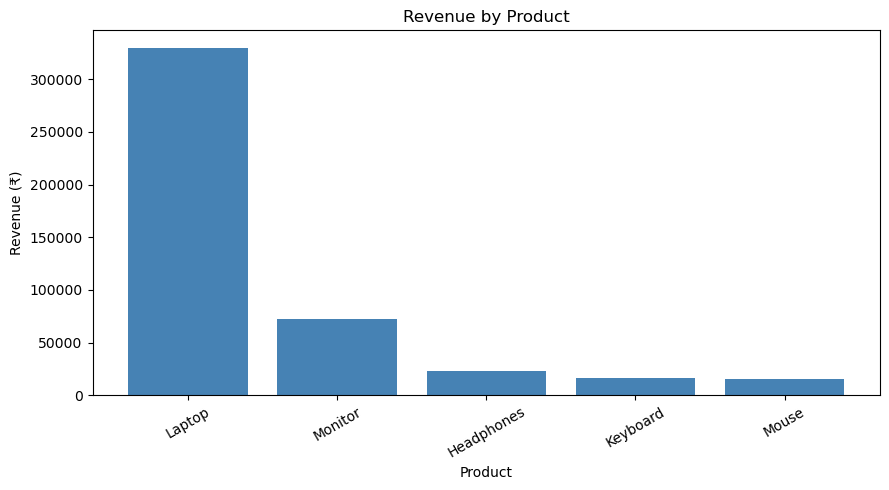

In [22]:
plt.figure(figsize=(9, 5))

plt.bar(
    product_analysis["product"],
    product_analysis["total_revenue"],
    color="steelblue"
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


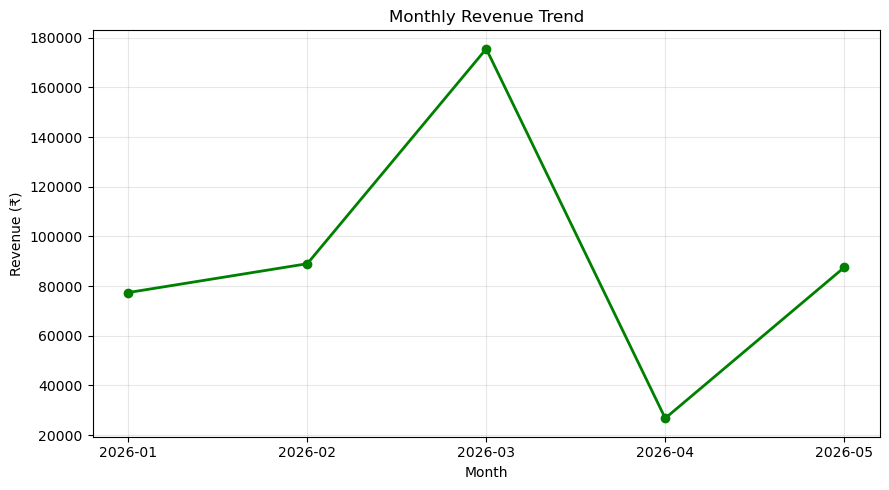

In [23]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_analysis["month"],
    monthly_analysis["monthly_revenue"],
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


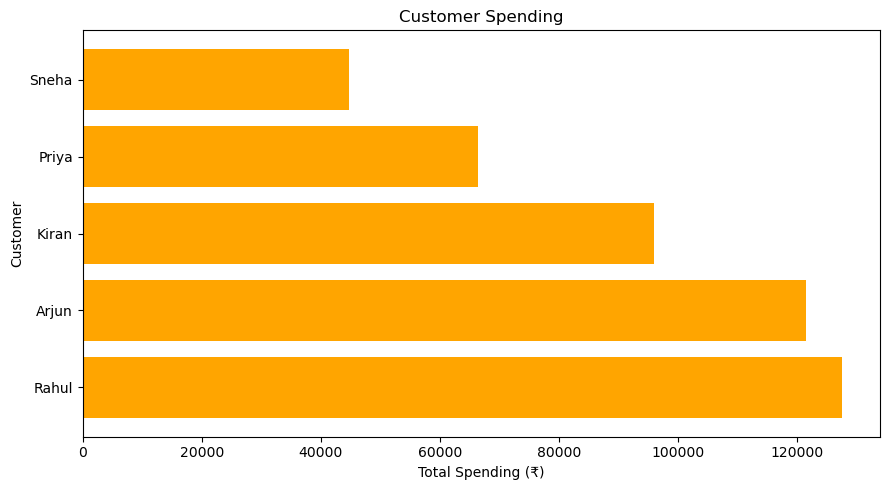

In [24]:
plt.figure(figsize=(9, 5))

plt.barh(
    customer_analysis["customer"],
    customer_analysis["total_spending"],
    color="orange"
)

plt.title("Customer Spending")
plt.xlabel("Total Spending (₹)")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()


In [25]:
print("=" * 60)
print("       E-COMMERCE SALES & CUSTOMER ANALYTICS")
print("=" * 60)

total_revenue = df["revenue"].sum()
total_orders = df["order_id"].nunique()
total_units = df["quantity"].sum()
average_order = df["revenue"].mean()

print(f"\nTotal Orders       : {total_orders}")
print(f"Total Units Sold   : {total_units}")
print(f"Total Revenue      : ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{average_order:,.2f}")

print("\nTop Products:")
display(product_analysis.head(3))

print("\nCustomer Ranking:")
display(customer_ranking)

print("\nMonthly Revenue:")
display(monthly_analysis)


       E-COMMERCE SALES & CUSTOMER ANALYTICS

Total Orders       : 20
Total Units Sold   : 51
Total Revenue      : ₹456,200.00
Average Order Value: ₹22,810.00

Top Products:


,product,units_sold,total_revenue
0,Laptop,6,330000
1,Monitor,6,72000
2,Headphones,9,22500



Customer Ranking:


,customer,total_spending,customer_rank
0,Rahul,127500,1
1,Arjun,121500,2
2,Kiran,96000,3
3,Priya,66400,4
4,Sneha,44800,5



Monthly Revenue:


,month,monthly_revenue
0,2026-01,77400
1,2026-02,89000
2,2026-03,175500
3,2026-04,26800
4,2026-05,87500


In [26]:
conn.close()

print("Project completed successfully!")


Project completed successfully!
